In [1]:
# This is our very first cell in the Jupyter Notebook.
# We can run this cell to make sure the Python kernel is working.
print("Hello, Jupyter! The analysis can now begin.")

Hello, Jupyter! The analysis can now begin.


In [2]:
import pandas as pd

file_path = '../data/IMDB Dataset.csv'

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully into a Pandas Dataframe")

Dataset Loaded Successfully into a Pandas Dataframe


In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [5]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [6]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

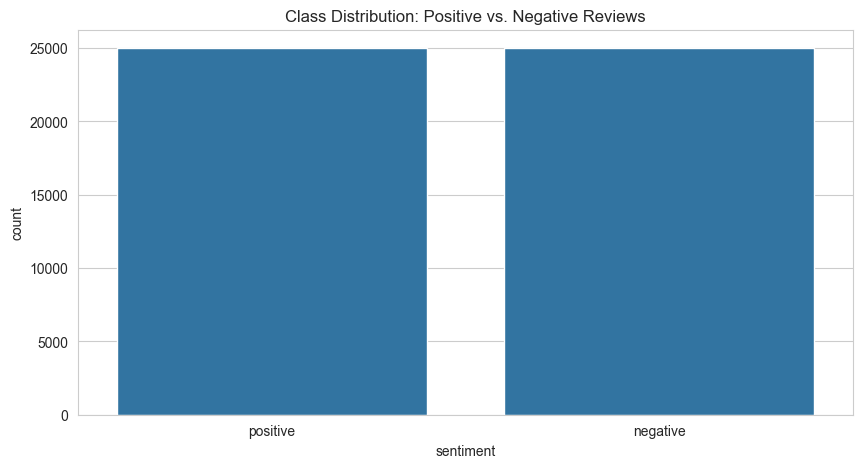

In [7]:
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set_style('whitegrid')

plt.figure(figsize = (10,5))
sns.countplot(x = 'sentiment', data = df)

plt.title('Class Distribution: Positive vs. Negative Reviews')

plt.show()

# DATA CLEANING

In [8]:
def to_lowercase(text):
    return text.lower()

In [9]:
example_text = "This is GREAT Movie! I Really enjoyed it."
cleaned_text = to_lowercase(example_text)

print("Original text", example_text)
print("Cleaned text :", cleaned_text)

Original text This is GREAT Movie! I Really enjoyed it.
Cleaned text : this is great movie! i really enjoyed it.


In [10]:
df['review'] = df['review'].apply(to_lowercase)

print("Data After applying lowercase.")
df.head()

Data After applying lowercase.


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [11]:
import re

def remove_htmltag(text):
    pattern = re.compile('<.*?>')
    return pattern.sub('', text)

example_text_with_html = "this was an <i>amazing</i> movie. i loved it! <br /><br />totally <b>worth</b> watching."
cleaned_text = remove_htmltag(example_text_with_html)

print("Original Text with HTML:  ", example_text_with_html)
print("Text after HTML removal:", cleaned_text)

Original Text with HTML:   this was an <i>amazing</i> movie. i loved it! <br /><br />totally <b>worth</b> watching.
Text after HTML removal: this was an amazing movie. i loved it! totally worth watching.


In [12]:
df['review'] = df['review'].apply(remove_htmltag)

print("DataFrame after removing HTML tags:")
df.head()

DataFrame after removing HTML tags:


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [13]:
import re 
def remove_punctuation(text):
    return re.sub(r'[^a-z0-9\s]', ' ', text).strip()

example_text_with_punc = "wow... this movie was *amazing*! (10/10). i'd say it's a 'must-see'."
cleaned_text = remove_punctuation(example_text_with_punc)

print("Original Text with Punctuation: ", example_text_with_punc)
print("Text after Punctuation Removal:", cleaned_text)

Original Text with Punctuation:  wow... this movie was *amazing*! (10/10). i'd say it's a 'must-see'.
Text after Punctuation Removal: wow    this movie was  amazing    10 10   i d say it s a  must see


In [14]:
df['review'] = df['review'].apply(remove_punctuation)

print("Data after removing punctuations .")
df.head()

Data after removing punctuations .


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there s a family where a little boy ...,negative
4,petter mattei s love in the time of money is...,positive


In [15]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Hari
[nltk_data]     Prasad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
from nltk.corpus import stopwords

english_stopwords_list = stopwords.words('english')
print("--- First 10 Stopwords from NLTK List ---")
print(english_stopwords_list[:10])
print("\n" + "="*50 + "\n")

--- First 10 Stopwords from NLTK List ---
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']




In [17]:
stop_words_set = set(english_stopwords_list)


In [18]:
print(f"We have successfully loaded {len(stop_words_set)} English stopwords into a highly efficient set.")



We have successfully loaded 198 English stopwords into a highly efficient set.


In [19]:
def tokenize_and_remove_stopwords(text):
    tokens = text.split()
    cleaned_tokens = [token for token in tokens if token not in stop_words_set]
    return cleaned_tokens

example_sentence = "this movie is just a brilliant and beautiful production"
cleaned_tokens_list = tokenize_and_remove_stopwords(example_sentence)

print("Original Sentence:", example_sentence)
print("Tokens after Stopword Removal:", cleaned_tokens_list)

Original Sentence: this movie is just a brilliant and beautiful production
Tokens after Stopword Removal: ['movie', 'brilliant', 'beautiful', 'production']


In [20]:

df['review'] = df['review'].apply(tokenize_and_remove_stopwords)

print("DataFrame after tokenization and stopword removal:")
df.head()

DataFrame after tokenization and stopword removal:


,review,sentiment
0,"[one, reviewers, mentioned, watching, 1, oz, e...",positive
1,"[wonderful, little, production, filming, techn...",positive
2,"[thought, wonderful, way, spend, time, hot, su...",positive
3,"[basically, family, little, boy, jake, thinks,...",negative
4,"[petter, mattei, love, time, money, visually, ...",positive


In [21]:
import nltk

nltk.download('wordnet')

[nltk_data] Downloading package wordnet to C:\Users\Hari
[nltk_data]     Prasad\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [22]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

print(f"The lemma for 'movies' is: {lemmatizer.lemmatize('movies')}")
print(f"The lemma for 'running' is: {lemmatizer.lemmatize('running')}")

The lemma for 'movies' is: movie
The lemma for 'running' is: running


In [23]:
def lemmatize_tokens(tokens):
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return lemmatized_tokens
    
example_tokens = ['movies', 'are', 'amazing', 'characters', 'were', 'running', 'studies']
lemmatized_example = lemmatize_tokens(example_tokens)

print("Original Tokens:", example_tokens)
print("Lemmatized Tokens:", lemmatized_example)

Original Tokens: ['movies', 'are', 'amazing', 'characters', 'were', 'running', 'studies']
Lemmatized Tokens: ['movie', 'are', 'amazing', 'character', 'were', 'running', 'study']


In [40]:
df['review'] = df['review'].apply(lemmatize_tokens)

print("DataFrame after applying the lemmatization function:")
df.head()

DataFrame after applying the lemmatization function:


,review,sentiment,cleaned_review
0,"[one, reviewer, mentioned, watching, 1, oz, ep...",positive,one reviewer mentioned watching 1 oz episode h...
1,"[wonderful, little, production, filming, techn...",positive,wonderful little production filming technique ...
2,"[thought, wonderful, way, spend, time, hot, su...",positive,thought wonderful way spend time hot summer we...
3,"[basically, family, little, boy, jake, think, ...",negative,basically family little boy jake think zombie ...
4,"[petter, mattei, love, time, money, visually, ...",positive,petter mattei love time money visually stunnin...


In [25]:
tokens = ['this', 'is', 'a', 'brilliant', 'movie']
separator = ' '
rejoined_string = separator.join(tokens)
print(rejoined_string)
# rejoined_string is now "this is a brilliant movie"

this is a brilliant movie


In [26]:
def join_tokens(tokens):
        return ' '.join(tokens)

example_lemmatized_tokens = ['movie', 'brilliant', 'beautiful', 'production', 'character', 'scene']
rejoined_text = join_tokens(example_lemmatized_tokens)

print("Original list of tokens:", example_lemmatized_tokens)
print("Rejoined string:", rejoined_text)

Original list of tokens: ['movie', 'brilliant', 'beautiful', 'production', 'character', 'scene']
Rejoined string: movie brilliant beautiful production character scene


In [27]:
df['cleaned_review'] = df['review'].apply(join_tokens)

print("DataFrame after final cleaning and rejoining tokens:")
df[['review', 'cleaned_review', 'sentiment']].head()

DataFrame after final cleaning and rejoining tokens:


,review,cleaned_review,sentiment
0,"[one, reviewer, mentioned, watching, 1, oz, ep...",one reviewer mentioned watching 1 oz episode h...,positive
1,"[wonderful, little, production, filming, techn...",wonderful little production filming technique ...,positive
2,"[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...,positive
3,"[basically, family, little, boy, jake, think, ...",basically family little boy jake think zombie ...,negative
4,"[petter, mattei, love, time, money, visually, ...",petter mattei love time money visually stunnin...,positive


# FEATURE ENGINEERING 

In [28]:
X = df['cleaned_review']

y = df['sentiment']

print("--- Features (X) ---")
print(X.head())
print("\n" + "="*50 + "\n") # A clean separator
print("--- Target (y) ---")
print(y.head())

--- Features (X) ---
0    one reviewer mentioned watching 1 oz episode h...
1    wonderful little production filming technique ...
2    thought wonderful way spend time hot summer we...
3    basically family little boy jake think zombie ...
4    petter mattei love time money visually stunnin...
Name: cleaned_review, dtype: str


--- Target (y) ---
0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: str


In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (40000,)
Shape of X_test: (10000,)
Shape of y_train: (40000,)
Shape of y_test: (10000,)


In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=10000)

print("TfidfVectorizer initialized successfully:")
print(tfidf_vectorizer)

TfidfVectorizer initialized successfully:
TfidfVectorizer(max_features=10000)


In [43]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

print("Successfully fitted the vectorizer and transformed the training data.")


Successfully fitted the vectorizer and transformed the training data.


In [44]:
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Successfully transformed the testing data.")

Successfully transformed the testing data.


In [45]:
print("Shape of the TF-IDF training data matrix (X_train_tfidf):", X_train_tfidf.shape)

print("Shape of the TF-IDF testing data matrix (X_test_tfidf):", X_test_tfidf.shape)


Shape of the TF-IDF training data matrix (X_train_tfidf): (40000, 10000)
Shape of the TF-IDF testing data matrix (X_test_tfidf): (10000, 10000)


# FITTING MODEL

In [46]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)

print("Logistic Regression model initialized successfully:")
print(lr_model)

Logistic Regression model initialized successfully:
LogisticRegression(random_state=42)


In [47]:
lr_model.fit(X_train_tfidf, y_train)

print("The Logistic Regression model has been successfully trained.")


The Logistic Regression model has been successfully trained.


In [48]:
y_pred = lr_model.predict(X_test_tfidf)

print("First 20 predictions made by the model:")
print(y_pred[:20])

print("\n" + "="*50 + "\n")
print("Comparison of first 5 Predictions vs. Actual Labels:")
print("Predictions:", y_pred[:5])
print("Actuals:    ", y_test.values[:5])

First 20 predictions made by the model:
['negative' 'negative' 'positive' 'negative' 'negative' 'negative'
 'negative' 'negative' 'negative' 'negative' 'negative' 'positive'
 'positive' 'negative' 'positive' 'positive' 'positive' 'positive'
 'positive' 'positive']


Comparison of first 5 Predictions vs. Actual Labels:
Predictions: ['negative' 'negative' 'positive' 'negative' 'negative']
Actuals:     <StringArray>
['negative', 'negative', 'positive', 'negative', 'negative']
Length: 5, dtype: str


In [50]:
from sklearn.metrics import classification_report, confusion_matrix

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      5000
    positive       0.89      0.91      0.90      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [51]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4417  583]
 [ 474 4526]]


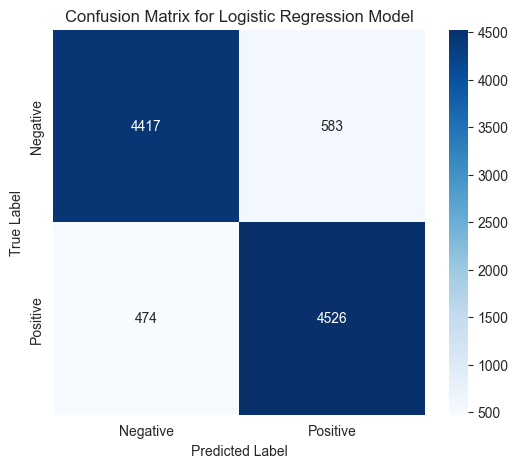

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

class_names = ['Negative', 'Positive']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()

 # * Model Persistence

In [53]:
import joblib

model_filename = 'lr_model.pkl'
joblib.dump(lr_model, model_filename)

print(f"Model saved successfully to '{model_filename}'")


Model saved successfully to 'lr_model.pkl'


In [54]:
import joblib

# filename for saving vectorizer
vectorizer_filename = "tfidf_vectorizer.pkl"

# save fitted vectorizer
joblib.dump(tfidf_vectorizer, vectorizer_filename)

print(f"Vectorizer saved successfully to '{vectorizer_filename}'")

Vectorizer saved successfully to 'tfidf_vectorizer.pkl'


In [55]:
import os
print(os.listdir())

['.ipynb_checkpoints', '01-data-exploration-and-cleaning.ipynb', 'app.py', 'lr_model.pkl', 'test_api.py', 'tfidf_vectorizer.pkl']


# Future use of this Model 

In [48]:
# load saved files
model = joblib.load("lr_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

# new review
review = ["This movie is fantastic"]

# convert text -> numbers
review_vector = vectorizer.transform(review)

# predict
prediction = model.predict(review_vector)

print(prediction)

['positive']


In [49]:
!pip install tensorflow

In [50]:
import sys
print(sys.version)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [56]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense



In [58]:
VOCAB_SIZE = 1000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")

tokenizer.fit_on_texts(X_train)

print(f"The tokenizer has learned a vocabulary of {len(tokenizer.word_index)} words.")

print("\nExample word-to-index mappings:")
print(f"movie -> {tokenizer.word_index.get('movie')}")
print(f"film -> {tokenizer.word_index.get('film')}")
print(f"good -> {tokenizer.word_index.get('good')}")
print(f"bad -> {tokenizer.word_index.get('bad')}")

The tokenizer has learned a vocabulary of 84780 words.

Example word-to-index mappings:
movie -> 2
film -> 3
good -> 7
bad -> 19


In [59]:
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

print("--- Original Text Review (from X_train) ---")
print(X_train.iloc[0])

print("\n--- Same Review Converted to an Integer Sequence ---")
print(X_train_sequences[0])

--- Original Text Review (from X_train) ---
caught little gem totally accident back 1980 81 revival theatre see two old silly sci fi movie theatre packed full warning showed bunch sci fi short spoof get u mood somewhat amusing came within second audience hysteric biggest laugh came showed princess laia huge cinnamon bun instead hair head look camera give grim smile nod made even funnier gotta see chewabacca played look like muppet extremely silly stupid stop laughing dialogue drowned laughter also know star war pretty well even funnier deliberately poke fun dialogue really work audience definite 10

--- Same Review Converted to an Integer Sequence ---
[918, 47, 1, 352, 1, 61, 1, 1, 1, 1, 13, 35, 70, 543, 735, 728, 2, 1, 1, 258, 1, 1, 622, 735, 728, 215, 1, 12, 75, 1, 540, 997, 280, 625, 190, 156, 1, 978, 206, 280, 1, 1, 1, 521, 1, 1, 198, 963, 248, 44, 231, 60, 1, 1, 1, 27, 10, 1, 1, 13, 1, 161, 44, 5, 1, 462, 543, 260, 382, 892, 284, 1, 1, 22, 32, 94, 165, 93, 17, 10, 1, 1, 1, 147, 28

In [60]:
print("\n--- Verifying Sequence Lengths ---")
print(f"Length of first training sequence: {len(X_train_sequences[0])}")
print(f"Length of second training sequence: {len(X_train_sequences[1])}")
print(f"Length of first testing sequence: {len(X_test_sequences[0])}")


--- Verifying Sequence Lengths ---
Length of first training sequence: 90
Length of second training sequence: 88
Length of first testing sequence: 70


In [61]:
MAX_LEN = 200

X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print("--- Shape of Padded Data ---")
print("Shape of X_train_padded:", X_train_padded.shape)
print("Shape of X_test_padded:", X_test_padded.shape)

print("\n--- Example of a Padded Sequence (from X_train_padded) ---")
print(X_train_padded[0])

--- Shape of Padded Data ---
Shape of X_train_padded: (40000, 200)
Shape of X_test_padded: (10000, 200)

--- Example of a Padded Sequence (from X_train_padded) ---
[918  47   1 352   1  61   1   1   1   1  13  35  70 543 735 728   2   1
   1 258   1   1 622 735 728 215   1  12  75   1 540 997 280 625 190 156
   1 978 206 280   1   1   1 521   1   1 198 963 248  44 231  60   1   1
   1  27  10   1   1  13   1 161  44   5   1 462 543 260 382 892 284   1
   1  22  32  94 165  93  17  10   1   1   1 147 284  15  53 156   1  74
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]


In [62]:
label_mapping = {'positive': 1, 'negative': 0}

y_train_final = y_train.map(label_mapping)
y_test_final = y_test.map(label_mapping)

print("\n--- Converted Numerical Labels (from y_train_final) ---")
print(y_train_final.head())


--- Converted Numerical Labels (from y_train_final) ---
47808    1
20154    0
43069    0
19413    0
13673    0
Name: sentiment, dtype: int64


In [ ]:
# # EMBEDDING_DIM = 128
# # LSTM_UNITS = 64

# # model = Sequential()

# # model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))

# # model.add(LSTM(units=LSTM_UNITS, dropout=0.2, recurrent_dropout=0.2))

# # model.add(Dense(units=1, activation='sigmoid'))

# # model.summary()

# EMBEDDING_DIM = 128
# LSTM_UNITS = 64

# model = Sequential()

# model.add(
#     Embedding(
#         input_dim=VOCAB_SIZE,
#         output_dim=EMBEDDING_DIM
#     )
# )

# model.add(
#     LSTM(
#         units=LSTM_UNITS,
#         dropout=0.2,
#         recurrent_dropout=0.2
#     )
# )

# model.add(
#     Dense(units=1, activation='sigmoid')
# )

# model.summary()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input

EMBEDDING_DIM = 128
LSTM_UNITS = 64

model = Sequential()

# Explicit input layer
model.add(Input(shape=(MAX_LEN,)))

# Embedding layer
model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
        
    )
)

# LSTM layer
model.add(
    LSTM(
        units=LSTM_UNITS,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)

# Output layer
model.add(Dense(units=1, activation='sigmoid'))

# Show architecture
model.summary()

In [64]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Input

VOCAB_SIZE = 10000
MAX_LEN = 200
EMBEDDING_DIM = 128

model = Sequential()

# Explicit input shape
model.add(Input(shape=(MAX_LEN,)))

# Embedding layer
model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    )
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 200, 128)            │       1,280,000 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,280,000 (4.88 MB)

 Trainable params: 1,280,000 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:

VOCAB_SIZE = 10000
MAX_LEN = 200
EMBEDDING_DIM = 128
LSTM_UNITS = 64

model = Sequential()

# Explicit input layer
model.add(Input(shape=(MAX_LEN,)))

# Embedding layer
model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    )
)

# LSTM layer
model.add(
    LSTM(
        units=LSTM_UNITS,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)

print("Model summary after adding the LSTM layer:")
model.summary()

Model summary after adding the LSTM layer:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,329,408 (5.07 MB)

 Trainable params: 1,329,408 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:

VOCAB_SIZE = 10000
MAX_LEN = 200
EMBEDDING_DIM = 128
LSTM_UNITS = 64

model = Sequential()
model.add(Input(shape=(MAX_LEN,)))

model.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
  
))
model.add(LSTM(
    units=LSTM_UNITS,
    dropout=0.2,
    recurrent_dropout=0.2
))

model.add(Dense(
    units=1,

    activation='sigmoid'
))

print("Final model summary:")
model.summary()

Final model summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:

model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

print("Model has been sucessfully compiled and is reasy for training.")

Model has been sucessfully compiled and is reasy for training.


In [68]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))
print(tf.__version__)

[]
2.21.0


# TRAINING NEURAL NETWORK MODEL

In [69]:
EPOCHS = 6
BATCH_SIZE = 64

history = model.fit(
    X_train_padded,
    y_train_final,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
      validation_data=(X_test_padded, y_test_final)
)

print("\nModel training complete!")


Epoch 1/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 133ms/step - accuracy: 0.5113 - loss: 0.6921 - val_accuracy: 0.5109 - val_loss: 0.6865
Epoch 2/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 123ms/step - accuracy: 0.5437 - loss: 0.6830 - val_accuracy: 0.5315 - val_loss: 0.6839
Epoch 3/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 121ms/step - accuracy: 0.7050 - loss: 0.5260 - val_accuracy: 0.8509 - val_loss: 0.3536
Epoch 4/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 123ms/step - accuracy: 0.8589 - loss: 0.3376 - val_accuracy: 0.8588 - val_loss: 0.3217
Epoch 5/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 124ms/step - accuracy: 0.8724 - loss: 0.3066 - val_accuracy: 0.8660 - val_loss: 0.3121
Epoch 6/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 128ms/step - accuracy: 0.8780 - loss: 0.2910 - val_accuracy: 0.8631 - val_loss: 0.3193

Model training complete!


Keys available in history object: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


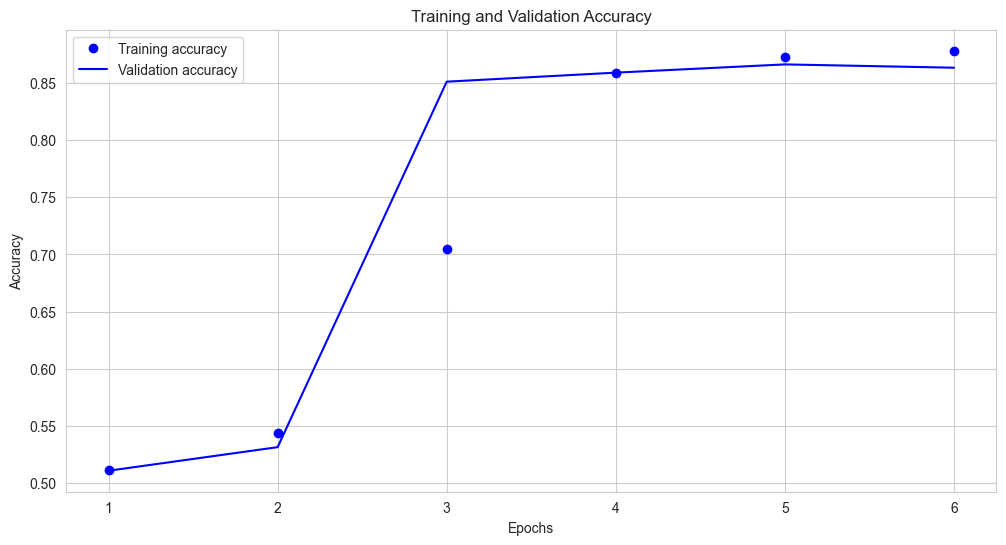

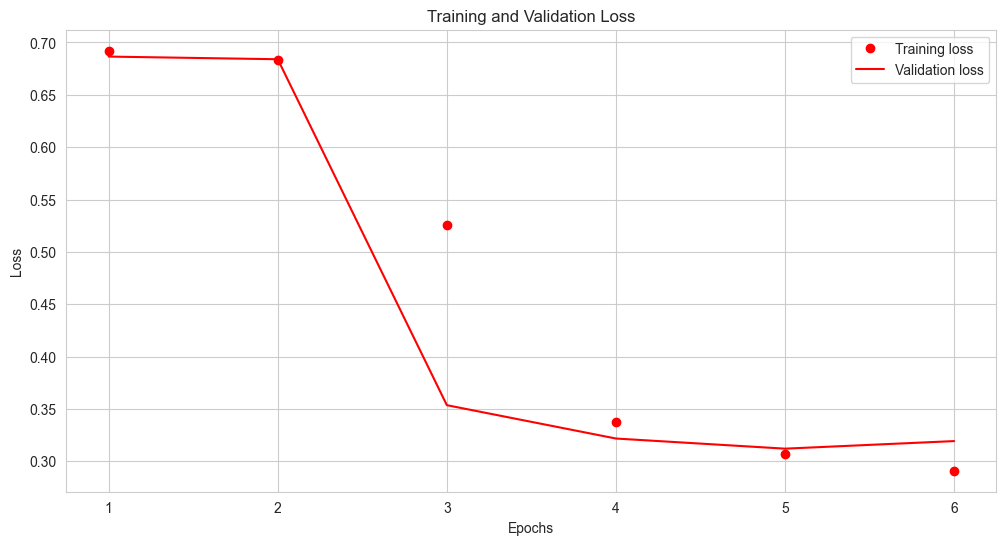

In [71]:
import matplotlib.pyplot as plt

history_dict = history.history
print("Keys available in history object:", history_dict.keys())

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 6))

plt.plot(epochs, acc, 'bo', label='Training accuracy')

plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()

plt.show()


plt.figure(figsize=(12, 6))
plt.plot(epochs, loss, 'ro', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [72]:
final_loss, final_accuracy = model.evaluate(X_test_padded, y_test_final, verbose=2)

print(f"\nFinal LSTM Model Performance on Test Data:")
print(f"Loss: {final_loss:.4f}")
print(f"Accuracy: {final_accuracy:.4f} ({(final_accuracy * 100):.2f}%)")

313/313 - 5s - 16ms/step - accuracy: 0.8631 - loss: 0.3193

Final LSTM Model Performance on Test Data:
Loss: 0.3193
Accuracy: 0.8631 (86.31%)


In [73]:
y_pred_probs = model.predict(X_test_padded)
y_pred_lstm = [1 if prob > 0.5 else 0 for prob in y_pred_probs.flatten()]


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


\n--- LSTM Model Classification Report ---
              precision    recall  f1-score   support

    Negative       0.90      0.82      0.86      5000
    Positive       0.83      0.91      0.87      5000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000


--- LSTM Model Confusion Matrix ---


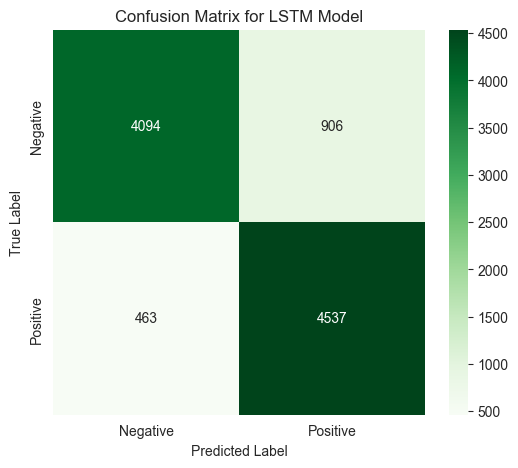

In [74]:
# --- Classification Report ---
print("\\n--- LSTM Model Classification Report ---")
print(classification_report(y_test_final, y_pred_lstm, target_names=['Negative', 'Positive']))

# --- Confusion Matrix ---
print("\n--- LSTM Model Confusion Matrix ---")
cm_lstm = confusion_matrix(y_test_final, y_pred_lstm)
class_names = ['Negative', 'Positive']

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for LSTM Model')
plt.show()

In [89]:
!pip install Flask

  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached werkzeug-3.1.8-py3-none-any.whl.metadata (4.0 kB)
Using cached flask-3.1.3-py3-none-any.whl (103 kB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
Using cached itsdangerous-2.2.0-py3-none-any.whl (16 kB)
Using cached werkzeug-3.1.8-py3-none-any.whl (226 kB)

   ---------------------------------------- 0/4 [werkzeug]
   ------------------------------ --------- 3/4 [Flask]
   ---------------------------------------- 4/4 [Flask]



In [76]:
import joblib

model = joblib.load('lr_model.pkl')
vectorizer = joblib.load('tfidf_vectorizer.pkl')

In [77]:
sample1 = "This movie was absolutely brilliant"
sample2 = "Worst boring terrible movie"

v1 = vectorizer.transform([sample1])
v2 = vectorizer.transform([sample2])

print(model.predict(v1))
print(model.predict(v2))

['positive']
['negative']


# * CREATING USER INTERFACE FOR THIS MODEL

In [78]:
!pip install streamlit requests

  Using cached streamlit-1.57.0-py3-none-any.whl.metadata (9.6 kB)
  Using cached altair-6.1.0-py3-none-any.whl.metadata (11 kB)
  Using cached gitpython-3.1.50-py3-none-any.whl.metadata (14 kB)
  Using cached pydeck-0.9.2-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached watchdog-6.0.0-py3-none-win_amd64.whl.metadata (44 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached smmap-5.0.3-py3-none-any.whl.metadata (4.6 kB)
Using cached streamlit-1.57.0-py3-none-any.whl (9.2 MB)
Using cached altair-6.1.0-py3-none-any.whl (796 kB)
Using cached gitpython-3.1.50-py3-none-any.whl (212 kB)
Using cached gitdb-4.0.12-py3-none-any.whl (62 kB)
Using cached pydeck-0.9.2-py2.py3-none-any.whl (11.3 MB)
Using cached smmap-5.0.3-py3-none-any.whl (24 kB)
Using cached tenacity-9.1.4-py3-none-any.whl (28 kB)
Using cached toml-0.10.2-py2.py3-none